In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, classification_report
)
from sklearn.model_selection import train_test_split

import joblib


In [18]:
# notebook is inside: .../diabetes_project/notebooks/
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)


PROJECT_DIR: C:\Users\LENOVO\diabetes_project
DATA_DIR: C:\Users\LENOVO\diabetes_project\data
MODELS_DIR: C:\Users\LENOVO\diabetes_project\models


In [19]:
clean_path = os.path.join(DATA_DIR, "diabetes_cleaned4.csv")
raw_path   = os.path.join(DATA_DIR, "diabetes_dataset.csv")

data_path = clean_path if os.path.exists(clean_path) else raw_path
print("Using dataset:", data_path)

df = pd.read_csv(data_path, keep_default_na=False)
df.columns = df.columns.str.strip().str.replace(" ", "_")

df.shape, df.head()


Using dataset: C:\Users\LENOVO\diabetes_project\data\diabetes_cleaned4.csv


((10000, 12),
    Age     Sex Ethnicity   BMI  Waist_Circumference  Fasting_Blood_Glucose  \
 0   58  Female     White  35.8                 83.4                  123.9   
 1   48    Male     Asian  24.1                 71.4                  183.7   
 2   34  Female     Black  25.0                113.8                  142.0   
 3   62    Male     Asian  32.7                100.4                  167.4   
 4   27  Female     Asian  33.5                110.8                  146.4   
 
    HbA1c Physical_Activity_Level  Dietary_Intake_Calories Alcohol_Consumption  \
 0   10.9                Moderate                     1538            Moderate   
 1   12.8                Moderate                     2653            Moderate   
 2   14.5                     Low                     1684               Heavy   
 3    8.8                     Low                     3796            Moderate   
 4    7.1                Moderate                     3161               Heavy   
 
   Smoking_Statu

In [20]:
target_col = "Diabetes"
fbg_col = "Fasting_Blood_Glucose"
lab_col = "HbA1c"

if target_col not in df.columns:
    if fbg_col not in df.columns:
        raise ValueError("❌ 'Diabetes' target not found and 'Fasting_Blood_Glucose' not found to create it.")

    # Convert to numeric safely
    df[fbg_col] = pd.to_numeric(df[fbg_col], errors="coerce")
    df[lab_col] = pd.to_numeric(df[lab_col], errors="coerce")

    df[target_col] = np.where(
        (df[fbg_col] >= 126) | (df[lab_col] >= 6.5),
        1,
        0
    )

    print("✅ Created Diabetes target using Fasting_Blood_Glucose ≥ 126 OR HbA1c ≥ 6.5")

df[target_col].value_counts()


✅ Created Diabetes target using Fasting_Blood_Glucose ≥ 126 OR HbA1c ≥ 6.5


Diabetes
1    9047
0     953
Name: count, dtype: int64

In [21]:
X = df.drop(columns=["Diabetes","Fasting_Blood_Glucose","HbA1c"])
y = df[target_col].astype(int)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((8000, 10), (2000, 10))

In [40]:
PIPELINE_PATH = os.path.join(MODELS_DIR, "diabetes_risk_pipeline.pkl")
THRESH_PATH   = os.path.join(MODELS_DIR, "best_threshold.pkl")

if not os.path.exists(PIPELINE_PATH):
    raise FileNotFoundError(f"Pipeline not found: {PIPELINE_PATH}")

pipeline = joblib.load(PIPELINE_PATH)

if os.path.exists(THRESH_PATH):
    best_threshold = float(joblib.load(THRESH_PATH))
else:
    best_threshold = 0.5  # fallback
    print("⚠️ Threshold file not found. Using 0.5")

print("✅ Pipeline loaded.")
print("✅ Threshold:", best_threshold)


✅ Pipeline loaded.
✅ Threshold: 0.89


In [41]:
y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

metrics_df = pd.DataFrame([metrics])
metrics_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.6695,0.911175,0.703151,0.79376,0.530529


In [42]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.11      0.35      0.17       191
           1       0.91      0.70      0.79      1809

    accuracy                           0.67      2000
   macro avg       0.51      0.53      0.48      2000
weighted avg       0.83      0.67      0.73      2000



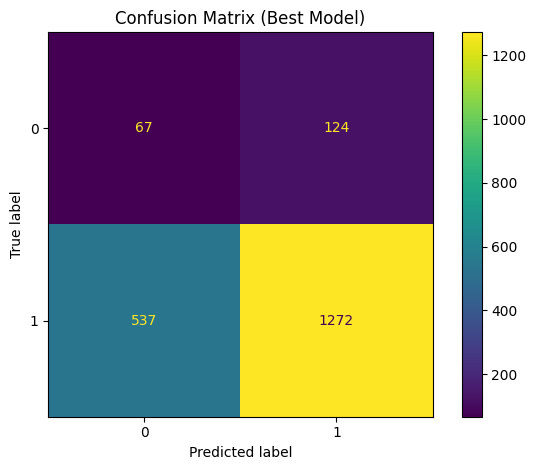

✅ Saved: C:\Users\LENOVO\diabetes_project\data\confusion_matrix_best_model.png


In [43]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix (Best Model)")
plt.tight_layout()

cm_path = os.path.join(DATA_DIR, "confusion_matrix_best_model.png")
plt.savefig(cm_path, dpi=300)
plt.show()

print("✅ Saved:", cm_path)


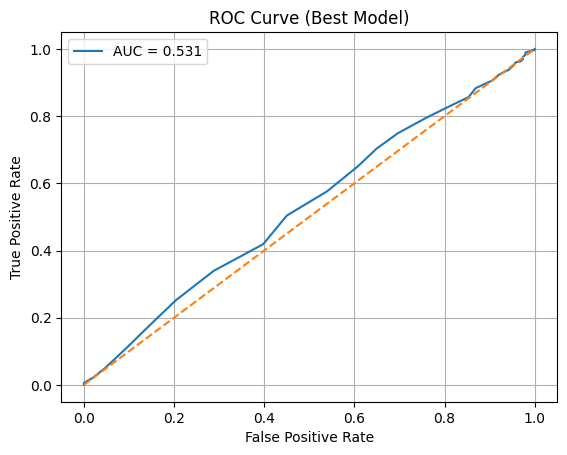

✅ Saved: C:\Users\LENOVO\diabetes_project\data\roc_curve_best_model.png


In [44]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Best Model)")
plt.legend()
plt.grid(True)

roc_path = os.path.join(DATA_DIR, "roc_curve_best_model.png")
plt.savefig(roc_path, dpi=300)
plt.show()

print("✅ Saved:", roc_path)


In [45]:
# If needed:
# !pip install shap

import shap


In [46]:
# Extract preprocessor and model from pipeline
preprocessor = pipeline.named_steps["preprocess"]
model = pipeline.named_steps["model"]

# Get transformed feature names (numeric + onehot)
num_features = preprocessor.named_transformers_["num"].named_steps["imputer"].feature_names_in_
cat_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]

cat_features = preprocessor.named_transformers_["cat"].named_steps["imputer"].feature_names_in_
cat_feature_names = cat_encoder.get_feature_names_out(cat_features)

all_feature_names = np.concatenate([num_features, cat_feature_names])

# Transform train/test into encoded arrays
X_train_enc = preprocessor.transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

print("Encoded train shape:", X_train_enc.shape)
print("Total transformed features:", len(all_feature_names))


Encoded train shape: (8000, 20)
Total transformed features: 20


In [47]:
# Choose explainer based on model type (fast for tree models)
model_name = type(model).__name__.lower()
print("Model type:", type(model))

if "randomforest" in model_name or "xgb" in model_name or "gradientboost" in model_name:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_enc)
else:
    # KernelExplainer is slower; sample background
    background = shap.sample(X_train_enc, 100, random_state=42)
    explainer = shap.KernelExplainer(model.predict_proba, background)
    shap_values = explainer.shap_values(shap.sample(X_test_enc, 50, random_state=42))  # sample for speed


Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


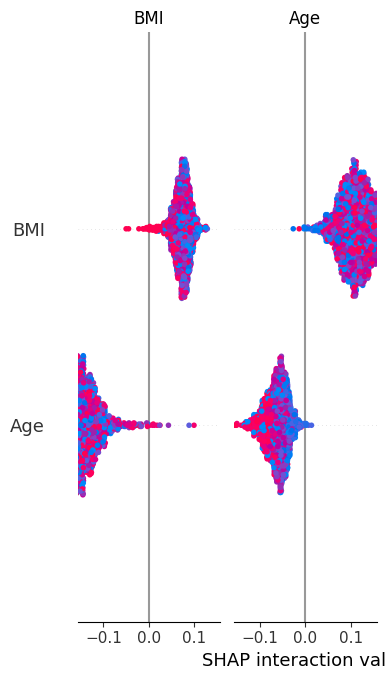

<Figure size 640x480 with 0 Axes>

✅ Saved: C:\Users\LENOVO\diabetes_project\data\shap_summary_beeswarm.png


In [56]:
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

shap.summary_plot(sv, X_test_enc, feature_names=all_feature_names)

plt.figure()

plt.tight_layout()

summary_path = os.path.join(DATA_DIR, "shap_summary_beeswarm.png")
plt.savefig(summary_path, dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved:", summary_path)


In [59]:
# ✅ Convert sv into a 2D matrix (n_samples, n_features) for the positive class (class 1)
if isinstance(sv, list):
    # For binary classification, take class 1
    sv_matrix = sv[1]
elif len(sv.shape) == 3:
    # Take class 1 from last dimension
    sv_matrix = sv[:, :, 1]
else:
    sv_matrix = sv

# ✅ Now mean_abs is 1D (n_features,)
mean_abs = np.abs(sv_matrix).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "MeanAbsSHAP": mean_abs
}).sort_values("MeanAbsSHAP", ascending=False)

importance_csv = os.path.join(DATA_DIR, "shap_global_importance.csv")
importance_df.to_csv(importance_csv, index=False)

print("✅ Saved:", importance_csv)
importance_df.head(15)

✅ Saved: C:\Users\LENOVO\diabetes_project\data\shap_global_importance.csv


,Feature,MeanAbsSHAP
3,Dietary_Intake_Calories,0.076236
2,Waist_Circumference,0.075317
1,BMI,0.073910
0,Age,0.063067
4,Family_History_of_Diabetes,0.013864
17,Smoking_Status_Current,0.008673
13,Physical_Activity_Level_Moderate,0.008471
11,Physical_Activity_Level_High,0.008170
16,Alcohol_Consumption_None,0.008098
7,Ethnicity_Asian,0.007932


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

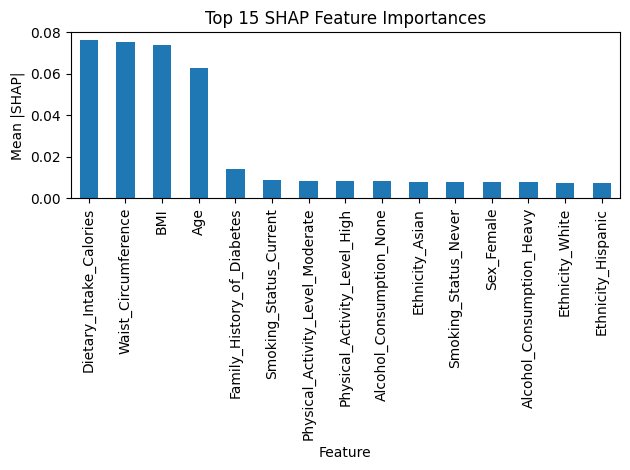

✅ Saved: C:\Users\LENOVO\diabetes_project\data\shap_feature_importance_bar.png


In [60]:
plt.figure()
importance_df.head(15).plot(kind="bar", x="Feature", y="MeanAbsSHAP", legend=False)
plt.title("Top 15 SHAP Feature Importances")
plt.ylabel("Mean |SHAP|")
plt.tight_layout()

bar_path = os.path.join(DATA_DIR, "shap_feature_importance_bar.png")
plt.savefig(bar_path, dpi=300)
plt.show()

print("✅ Saved:", bar_path)


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

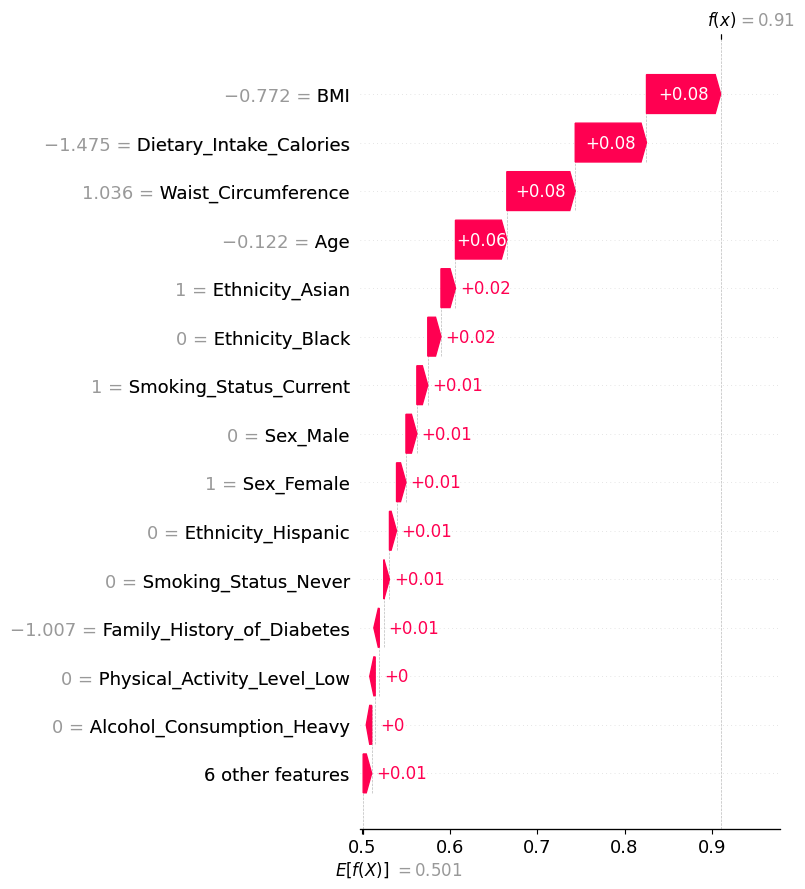

In [63]:
i = 0  # instance index

# If sv is a list: sv[1] is class 1
if isinstance(sv, list):
    row_sv = sv[1][i]     # shape (n_features,)
    base = explainer.expected_value[1]
else:
    # sv is array: (n_samples, n_features, n_classes)
    row_sv = sv[i, :, 1]  # class 1
    base = explainer.expected_value[1] if hasattr(explainer, "expected_value") else np.mean(model.predict_proba(X_train_enc)[:, 1])

exp = shap.Explanation(
    values=row_sv,
    base_values=base,
    data=X_test_enc[i],
    feature_names=all_feature_names
)

import matplotlib.pyplot as plt
plt.figure()
shap.plots.waterfall(exp, max_display=15, show=False)
plt.tight_layout()
plt.show()


In [64]:
# If needed:
# !pip install lime

from lime.lime_tabular import LimeTabularExplainer


In [65]:
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_enc),
    feature_names=all_feature_names,
    class_names=["No Diabetes", "Diabetes"],
    mode="classification"
)

print("✅ LIME explainer ready")


✅ LIME explainer ready


✅ Saved: C:\Users\LENOVO\diabetes_project\data\lime_local_explanation.html


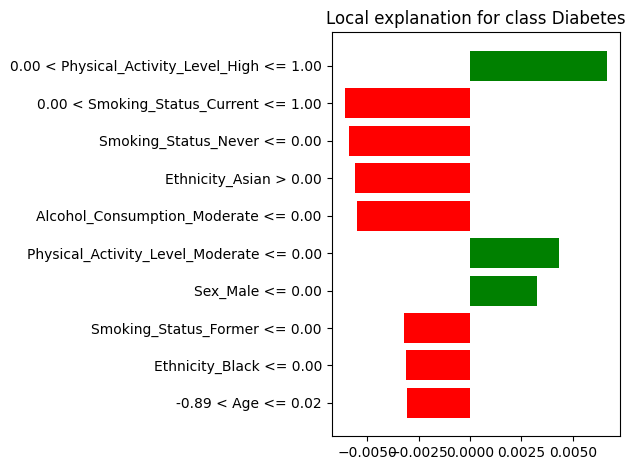

✅ Saved: C:\Users\LENOVO\diabetes_project\data\lime_local_explanation.png


In [66]:
i = 0
instance = np.array(X_test_enc[i])

lime_exp = lime_explainer.explain_instance(
    data_row=instance,
    predict_fn=model.predict_proba,
    num_features=10
)

# Save HTML
lime_html_path = os.path.join(DATA_DIR, "lime_local_explanation.html")
lime_exp.save_to_file(lime_html_path)
print("✅ Saved:", lime_html_path)

# Save as PNG using matplotlib
fig = lime_exp.as_pyplot_figure()
plt.tight_layout()

lime_png_path = os.path.join(DATA_DIR, "lime_local_explanation.png")
plt.savefig(lime_png_path, dpi=300)
plt.show()

print("✅ Saved:", lime_png_path)
